In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Before starting this assignment, you should read the following papers:
- Yonelinas, A. P. (1994). Receiver-Operating Characteristics in Recognition Memory: Evidence for a Dual-Process Model. Journal of Experimental Psychology. Learning, Memory, and Cognition, 20(6), 1341–1354. https://doi.org/10.1037/0278-7393.20.6.1341
- Wixted, J. T. (2007). Dual-process theory and signal-detection theory of recognition memory. Psychological Review, 114(1), 152–176. https://doi.org/10.1037/0033-295X.114.1.152



## Theory: Recognition memory

Recognition memory entails the ability to determine whether an item has been shown before (during a study phase) or not. 

#### Experimental paradigm
A typical experimental paradigm that probes recognition memory contains three phases:
1. The study phase, in which a list of stimuli/items is presented (e.g., 'cat', 'dog', 'elephant', 'mouse'). Participants are instructed to pay attention and remember the items that are presented
2. A retention phase, in which the participant engages in an unrelated task (for, e.g., 30 minutes)
3. A test phase, in which a new list of stimuli/items is presented, which contain both items that were shown before (**targets**; e.g., 'dog', 'mouse') and items that were not shown in the study phase (**distractors/lures**; e.g., 'rat', 'monkey'). For each item, the participant is asked whether the item was shown in the study phase or not ('yes' or 'no').


#### Empirical data
In the test phase, participants respond 'yes' or 'no' to the question of whether the item was present in the study phase. Each item could have been either a target or a distractor. This gives a total of four 'responses types':
- If the item was a target, and the participant correctly responded 'yes', we call this a 'hit'
- If the item was a target, and the participant incorrectly responded 'no', we call this a 'miss'
- If the item was a distractor, and the participant correctly responded 'no', we call this a 'correct rejection'
- If the item was a distractor, and the participant incorrectly responded 'yes', we call this a 'false alarm'

This is typically summarized in a decision matrix (or contingency table), where the *rows* refer to whether the stimulus was a target or a distractor, and the columns to the response of the participant:

|   | Respond "yes"  | Respond "no"  | 
|---|---|---|
| Target | hit  | miss  | 
| Distractor | false alarm |  correct rejection | 
| | | |

For each participant, the percentages of hits, misses, false alarms, and correct rejections can be calculated. Example data can look as follows:

In [6]:
# !wget -O memory_data1.csv https://surfdrive.surf.nl/s/nbRgD4DEFLtYXEf/download
# !wget -O memory_data2.csv https://surfdrive.surf.nl/s/FGfEQDTBZLLNC7J/download

data = pd.read_csv('csv/memory_data1.csv')
data.head()

,item,target_or_distractor,confidence,response
0,snob,target,5.0,no
1,face,distractor,1.0,yes
2,cashier,target,1.0,yes
3,trellis,target,3.0,yes
4,pun,target,2.0,yes


#### Assignment 1: Hit rates and false alarm rates

Using `data`, first make a contingency table. Then, calculate the hit rate and false alarm rate.

In [7]:
## your answer here
contingency = pd.crosstab(data['target_or_distractor'], data['response'])

hits = contingency.loc["target", "yes"]
misses = contingency.loc["target", "no"]
hit_rate = hits/(hits + misses)

false_alarm = contingency.loc["distractor", "yes"]
correct_rejections = contingency.loc["distractor", "no"]
false_alarm_rate = false_alarm/(correct_rejections + false_alarm)

print(f"hit rate :{hit_rate}")
print(f"false alarm rate :{false_alarm_rate}")
contingency.head()

hit rate :0.9456521739130435
false alarm rate :0.6724137931034483


response,no,yes
target_or_distractor,,
distractor,19,39
target,5,87


## Theory: Receiver-operator characteristic curves

Often, participants are also asked to rate how *confident* they were in their judgement. Assume that these confidence ratings are on a scale from 1 to 8, where 1 means "I am very confident that the item was shown in the study phase", and 8 means "I am very confident that the item was not shown in the study phase".

| Rating | Meaning |
| - | - |
| 1 | Very confident that I've seen this stimulus before ('yes') | 
| 2 | Confident that I've seen this stimulus before ('yes') | 
| 3 | Somewhat confident that I've seen this stimulus before ('yes') | 
| 4 | I'm guessing that I've seen this stimulus before ('yes') | 
| 5 | I'm guessing that I've not seen this stimulus before ('no') | 
| 6 | Somewhat confident that I've not seen this stimulus before ('no') | 
| 7 | Confident that I've seen not this stimulus before ('no') |
| 8 | Very confident that I've not seen this stimulus before ('no') |


A common way of visualizing the relation between false alarm rates is to plot a *receiver-operator characteristic* curve (ROC). To generate this plot, we calculate the hit rate and the false alarm rate for every confidence rating seperately. Specifically:
- We first calculate the hit rate and false alarm rate for only the responses with confidence = 1;
- We then calculate the hit rate and false alarm rate for only the responses with confidence = 1 OR 2;
- We then calculate the hit rate and false alarm rate for only the responses with confidence = 1 OR 2 OR 3;
- We then calculate the hit rate and false alarm rate for only the responses with confidence = 1 OR 2 OR 3 OR 4;
- etc
- Finally we calculate the hit rate and false alarm rate for all responses

**There is an important caveat: For each cumulative confidence level, calculate the hit rate and false alarm rate as proportions of the total number of targets and total number of lures, respectively.**

The ROC curve then plots the hit rate on the y-axis against the false alarm rate on the x-xaxis

#### Assignment 2: ROC curve

<div class='alert alert-warning'>
    <b>ToDo</b> Make a function that takes as input a pandas dataframe, and plots the ROC curve. Then use that function to plot the ROC curve of the `data`. It should look like this:
    <figure>
      <img src="https://surfdrive.surf.nl/s/EBqcjQtwrjJnPPn/download" alt="ROC" style="width:200pt">
      <figure>
</div>

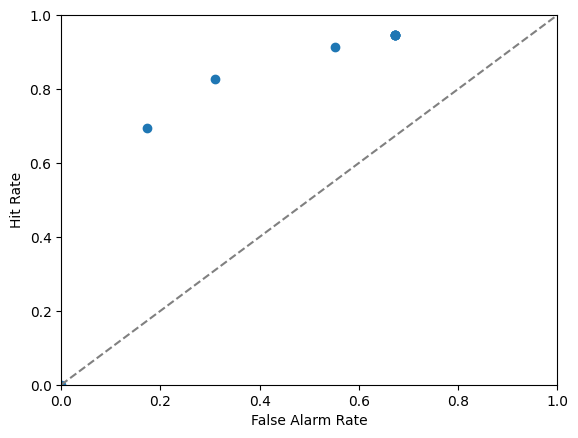

In [8]:
## your answer here
def table_population(info):
    table = np.zeros((8,2))

    cumulative = pd.DataFrame()
    counter = 1

    for counter in range(1, 9):
        new_rows = info[info["confidence"] == counter]
        cumulative = pd.concat([cumulative, new_rows])

        cumulative_contingency = pd.crosstab(cumulative['target_or_distractor'], cumulative['response'])

        hits = cumulative_contingency.loc["target", "yes"]
        total_targets = len(info[info["target_or_distractor"] == "target"])
        hit_rate = hits/total_targets
        table[counter-1][0] = hit_rate

        false_alarm = cumulative_contingency.loc["distractor", "yes"]
        total_lures = len(info[info["target_or_distractor"] == "distractor"])
        false_alarm_rate = false_alarm/total_lures
        table[counter-1][1] = false_alarm_rate

        counter += 1
    return table

plot_table = table_population(data)

xpoints = np.insert(plot_table[:, 1], 0, 0)
ypoints = np.insert(plot_table[:, 0], 0, 0)

plt.scatter(xpoints, ypoints, marker='o')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # diagonal chance line
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()


## Theory: Formal models
Now that we've explored what empirical data looks like, and how to visualize these data, we will next simulate three models of recognition memory.

- Model 1 assumes the participant did not pay any attention during the study phase, and only makes random guesses during the test phase
- Model 2 is the unequal-variance signal detection (UVSD) model, described by Wixted (2007)
- Model 3 is the dual-process signal detection (DPSD) model, also described by Wixted (2007)

### Formal Model 1: Random guessing

This is a toy model to help you get started, and illustrate what the ROC curve of random guesses look like. Let's begin fresh and assume that the following items were shown in an experiment:

In [27]:
model1_data = pd.read_csv('csv/memory_data2.csv')
model1_data

,item,target_or_distractor
0,ranger,target
1,server,distractor
2,toad,target
3,normal,target
4,lay,distractor
...,...,...
195,exhibit,target
196,reform,distractor
197,mascara,target
198,yew,target


Let's now simulate random guesses. The basic idea is that we assume that participants have a 'baseline memory strength' associated with each item, and that responses are based on those memory strengths

#### Assignment 3: Simulating random memory strengths

<div class='alert alert-warning'>
    <b>ToDo</b> Create a new column in `model1_data` called '`memory_strength`. Assign to each item in `model1_data` a random memory_strength, drawn from a normal (Gaussian) distribution, with mean 0 and sd 1.
</div>

In [57]:
# your answer here
model1_data = pd.read_csv("csv/memory_data2.csv")

model1_data["memory_strength"] = np.random.normal(loc=0, scale=1, size=len(model1_data))
print(model1_data)

           item target_or_distractor  memory_strength
0        ranger               target         0.353986
1        server           distractor         1.260447
2          toad               target        -1.128913
3        normal               target        -0.559370
4           lay           distractor        -0.742765
..          ...                  ...              ...
195     exhibit               target        -0.465027
196      reform           distractor        -0.752631
197     mascara               target         0.142368
198         yew               target        -0.793936
199  pilgrimage           distractor        -1.738346

[200 rows x 3 columns]


Once that's done, you can use the `get_confidence` function below to categorize responses

In [58]:
def get_cuts(n_confidence_bins=8, strength_for_max_confidence=1.5):
    bin_sizes = np.hstack(([-strength_for_max_confidence], np.ones(n_confidence_bins-2)*(3/(n_confidence_bins-2))))
    cuts = np.cumsum(bin_sizes)[::-1]
    return cuts

def get_confidence(memory_strength, n_confidence_bins=8, strength_for_max_confidence=1.5):
    ''' Based on memory strength, determine confidence rating.
    confidence rating = 1 means 'I am very sure this item is old (was shown in the study phase)'
    confidence rating = n_bins means 'I am very sure this item is new (was not shown in the study phase)'
    
    Items with a memory strength of >= strength_for_max_confidence will always get a maximum confidence rating (n_bins)
    Items with a memory strength of strength_for_maximum_confidence-3 will always get the minimum rating (1)
    The range in between [strength_for_maximum_confidence-3, strength_for_max_confidence] is cut into n_bins equally-sized bins
    '''
    cuts = get_cuts(n_confidence_bins, strength_for_max_confidence)
    cuts = np.hstack((cuts, [-np.inf]))
    
    # categorize
    confidence = np.zeros_like(memory_strength)
    for i in range(len(cuts)):
        if i == 1:
            idx = memory_strength > cuts[i]
        else:
            idx = (memory_strength < cuts[i-1]) & (memory_strength >= cuts[i])
        confidence[idx] = i
    
    return confidence


In [11]:
model1_data['confidence'] = get_confidence(model1_data['memory_strength'])

#### Assignment 4

<div class='alert alert-warning'>
    <b>ToDo</b> Plot the ROC curve of this model
</div>

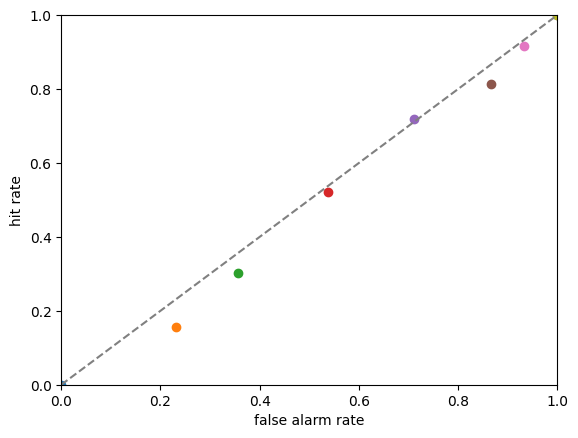

In [59]:
# your answer here
model1_data["confidence"] = get_confidence(model1_data["memory_strength"])

targets = model1_data[model1_data["target_or_distractor"] == "target"]
total_targets = len(targets)

distractors = model1_data[model1_data["target_or_distractor"] == "distractor"]
total_distractors = len(distractors)

hits_included = 0
false_alarms_included = 0
plt.plot(0,0, "o")

for confidence_level in range(1, 9):
    hits_included += len(targets[targets["confidence"] == confidence_level])
    false_alarms_included += len(distractors[distractors["confidence"] == confidence_level])

    hit_rate = hits_included / total_targets
    false_alarm_rate = false_alarms_included / total_distractors

    plt.plot(false_alarm_rate, hit_rate, "o")

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("false alarm rate")
plt.ylabel("hit rate")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

### Formal Model 2: UVSD

This model is described my Wixted (2007). It assumes that *distractors* (so items *not* shown in the study phase) have a 'baseline' memory strength, drawn from a Normal distribution with mean 0 and sd 1. *Targets* have a higher memory strength, drawn from a Normal distribution with mean > 0 and sd > 1. To begin simulating this model, start afresh again by loading the empty experimental paradigm:

In [47]:
model2_data = pd.read_csv('./memory_data2.csv')
model2_data

FileNotFoundError: [Errno 2] No such file or directory: './memory_data2.csv'

#### Assignment 5: Simulating memory strengths of the UVSD model

<div class='alert alert-warning'>
    <b>ToDo</b> Simulate the memory strengths. For all `distractor` items, the memory strength is drawn from a Normal distribution with mean=0 and sd=1. For all `target` items, draw from a Normal distribution with mean=2 and sd=2.
</div>

In [48]:
# your answer here

<div class='alert alert-warning'>
    <b>ToDo</b> Next, add the confidence ratings using the `get_confidence` function, and plot the ROC curve
</div>

In [49]:
# your answer here

### Formal Model 3: DPSD

This model is described by Wixted (2007) and by Yonelinas (1996). It assumes that there are two processes in recognition memory. One process is the *recollection* process, and implies that a proportion of all items is correctly remembered, and immediately assigned the maximum confidence rating (i.e., 1 or 8, depending on whether it was a distractor or a target). If recollection fails, then the second process starts, which is a judgement based on the *familiarity* of an item.
It assumes that *distractors* (so items *not* shown in the study phase) have a 'baseline' memory strength ('familiarity'), drawn from a Normal distribution with mean 0 and sd 1. *Targets* have a higher memory strength ('familiarity'), drawn from a Normal distribution with mean > 0 and sd = 1 (NB: so the *same* variance as the distractor items).

To begin simulating this model, start afresh again by loading the empty experimental paradigm:

In [50]:
model3_data = pd.read_csv('csv/memory_data2.csv')
model3_data

,item,target_or_distractor
0,ranger,target
1,server,distractor
2,toad,target
3,normal,target
4,lay,distractor
...,...,...
195,exhibit,target
196,reform,distractor
197,mascara,target
198,yew,target


#### Assignment 6 part 1: Simulate confidence ratings of recollected items

<div class='alert alert-warning'>
    <b>ToDo</b> Simulate process 1. Assume 20% of the items is correctly recollection, and immediately assign the highest confidence ratings (1 for targets, 8 for distractors) to these items
</div>

In [51]:
# your answer here

#### Assignment 6 part 2: Simulate memory strengths of the other items

<div class='alert alert-warning'>
    <b>ToDo</b> Simulate process 2. For the items that were *not* recollected, assign a `memory_strength`. For distractor items, the memory strength is drawn from a Normal distribution with mean 0 and sd 1; for target items, the memory strength is drawn from a Normal distribution with mean 1 and sd 1. After simulating these `memory_strengths`, assign confidence ratings using the `get_confidence` function
</div>

In [19]:
# your answer here

#### Assignment 7. Plot the ROC curve of the DPSD model

In [20]:
# your answer here